In [2]:
#data structures
import pandas as pd
import numpy as np
import os

#machine learning

#metrics (performace and machine learning scores)
import time #used for seeing how long it takes to run programs

%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)

In [3]:
os.getcwd()

'C:\\Users\\gdadzie\\Downloads'

In [4]:
df = pd.read_csv('data/diabetes_012.csv') #The data values of each building
df

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
253675,0.0,1.0,1.0,1.0,45.0,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,3.0,0.0,5.0,0.0,1.0,5.0,6.0,7.0
253676,2.0,1.0,1.0,1.0,18.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,4.0,0.0,0.0,1.0,0.0,11.0,2.0,4.0
253677,0.0,0.0,0.0,1.0,28.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,2.0,5.0,2.0
253678,0.0,1.0,0.0,1.0,23.0,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,3.0,0.0,0.0,0.0,1.0,7.0,5.0,1.0


## Exploration of data:

In [5]:
featureList = df.drop(['Diabetes_012'], axis = 1).columns.tolist()

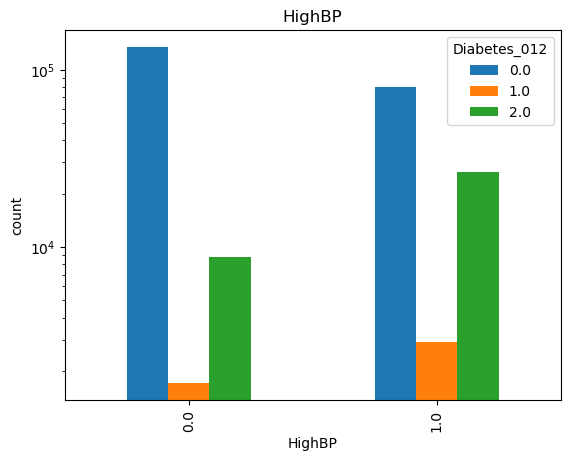

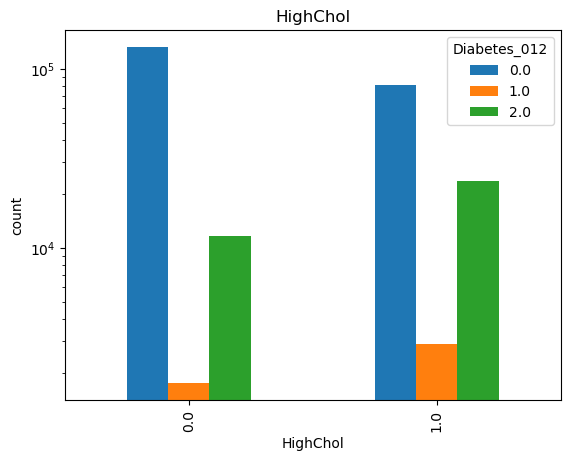

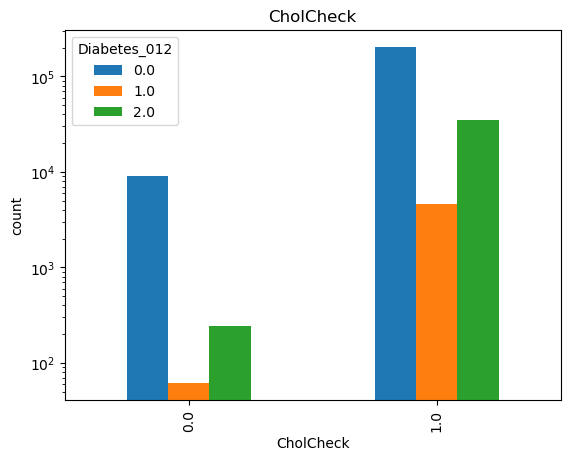

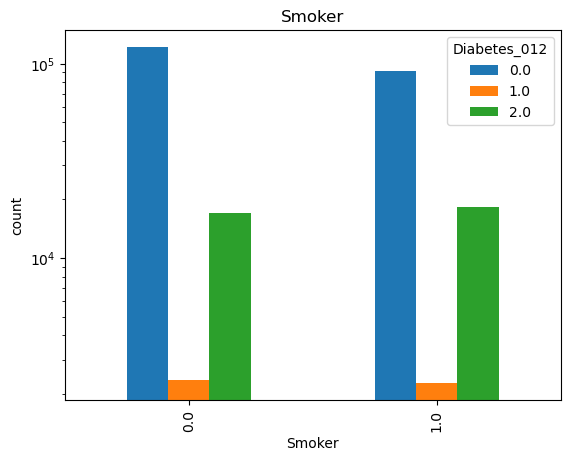

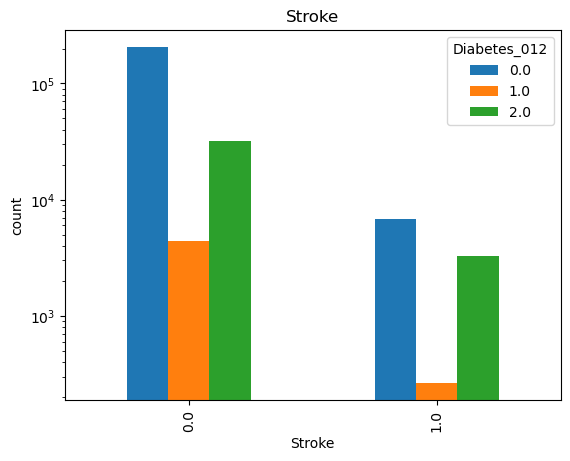

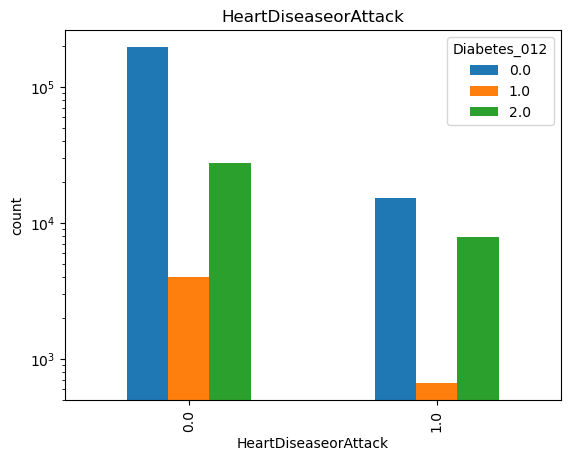

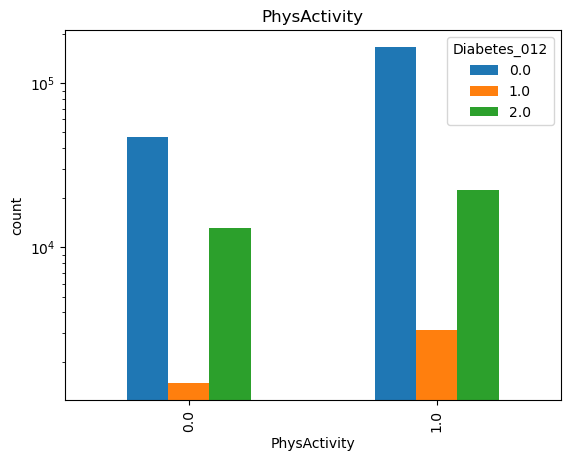

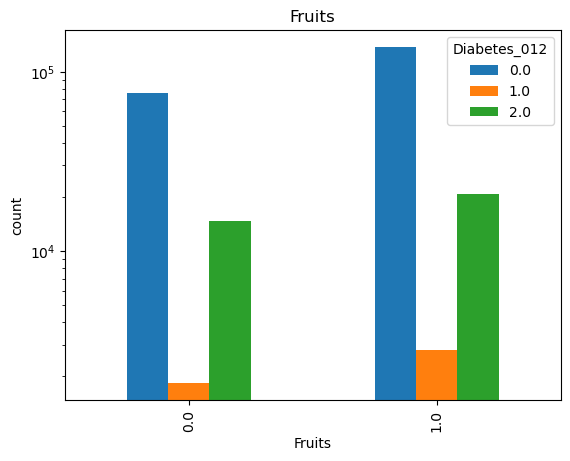

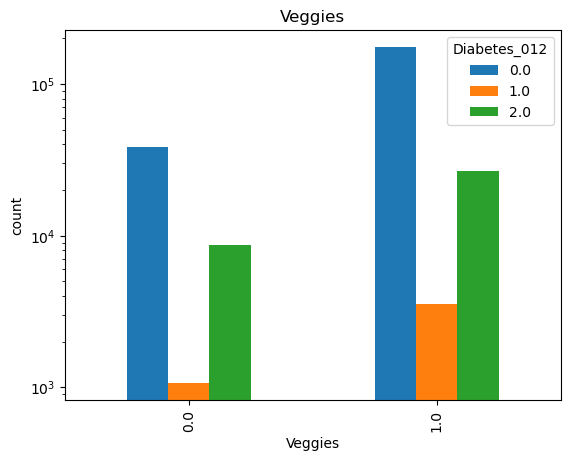

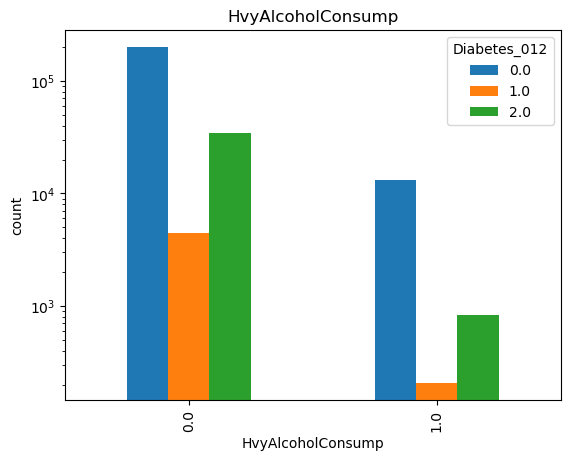

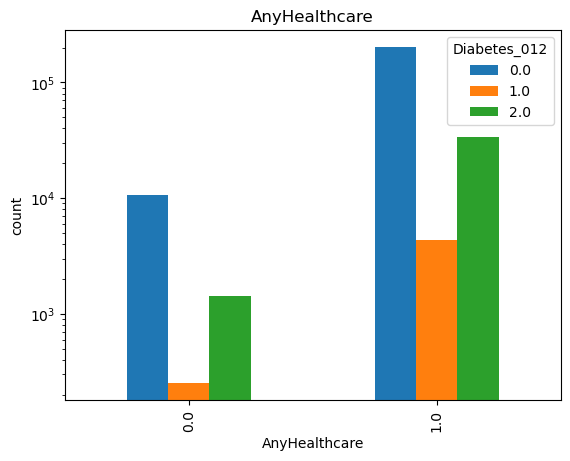

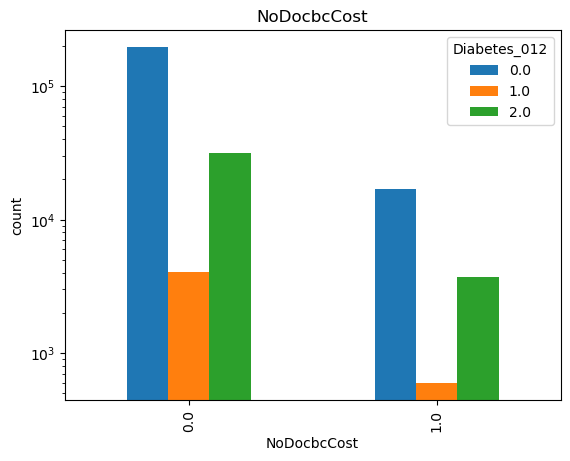

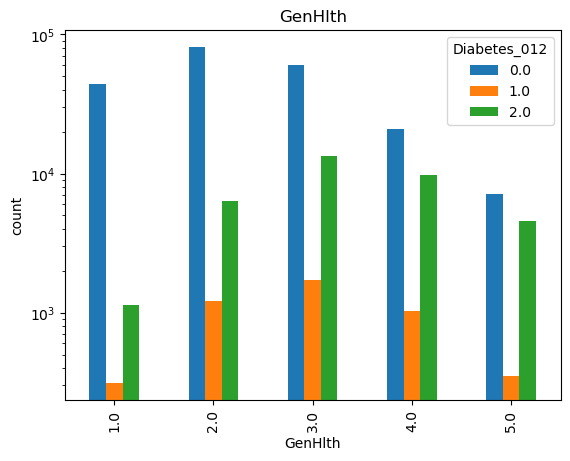

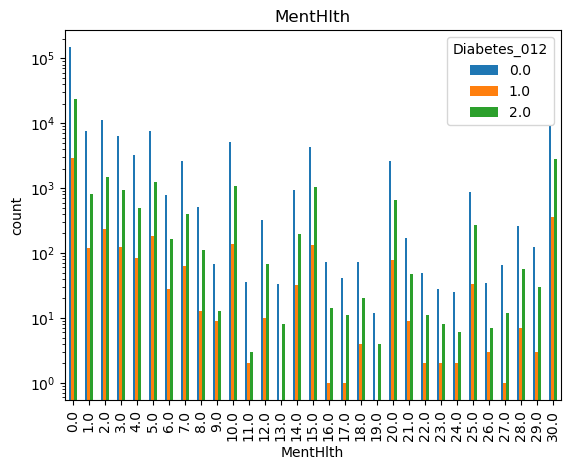

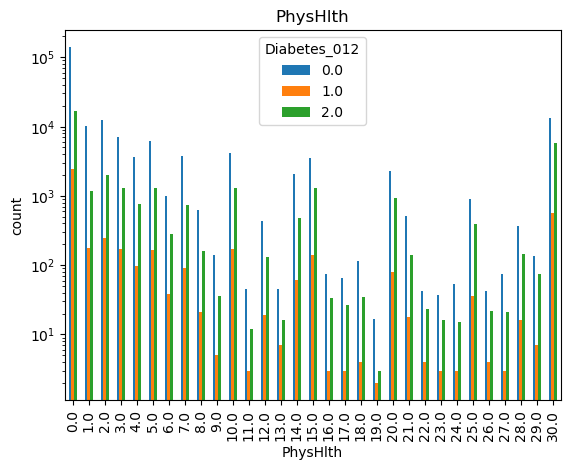

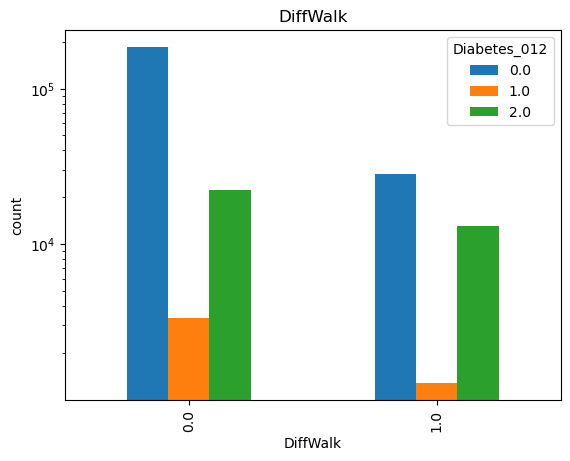

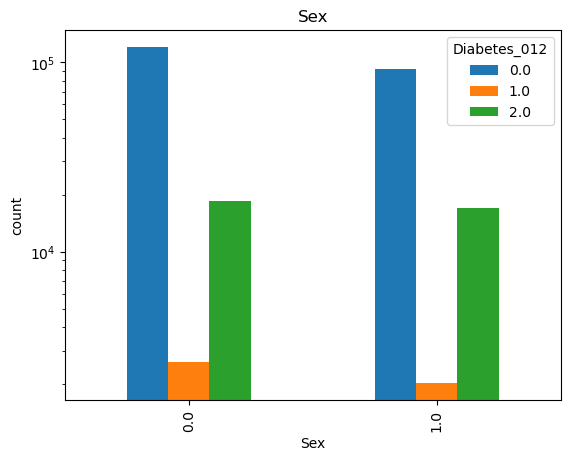

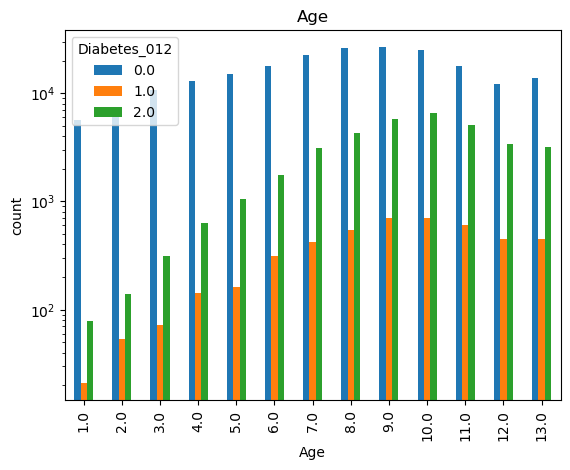

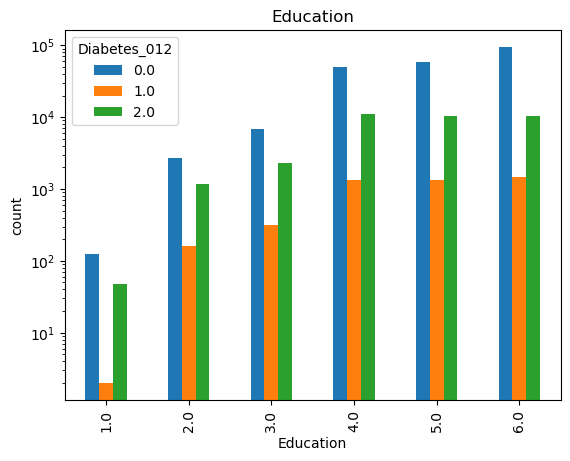

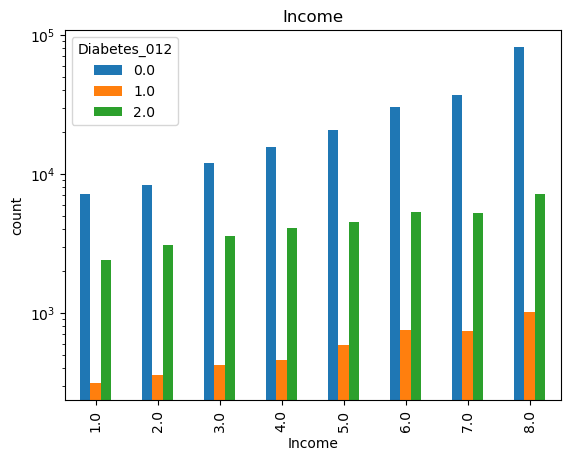

In [6]:
for column in featureList:
    data = df[['Diabetes_012', column]]
    g = data.groupby(['Diabetes_012', column])
    categoryTable = g.size().reset_index()
    categoryTable.columns = ['Diabetes_012', column, 'count']
    pivotTable = categoryTable.pivot(index = 'Diabetes_012', columns = column, values = 'count')
    pivotTable = pivotTable.fillna(0)
    # print(pivotTable)
    #plot if number of columns isn't too high
    numCol = len(pivotTable.columns)
    if(numCol < 32):
        pivotTable.T.plot(kind='bar')
        plt.title(column)
        plt.yscale('log')
        plt.ylabel('count')
        plt.show()

# Identify which variables are most associated with diabetes.

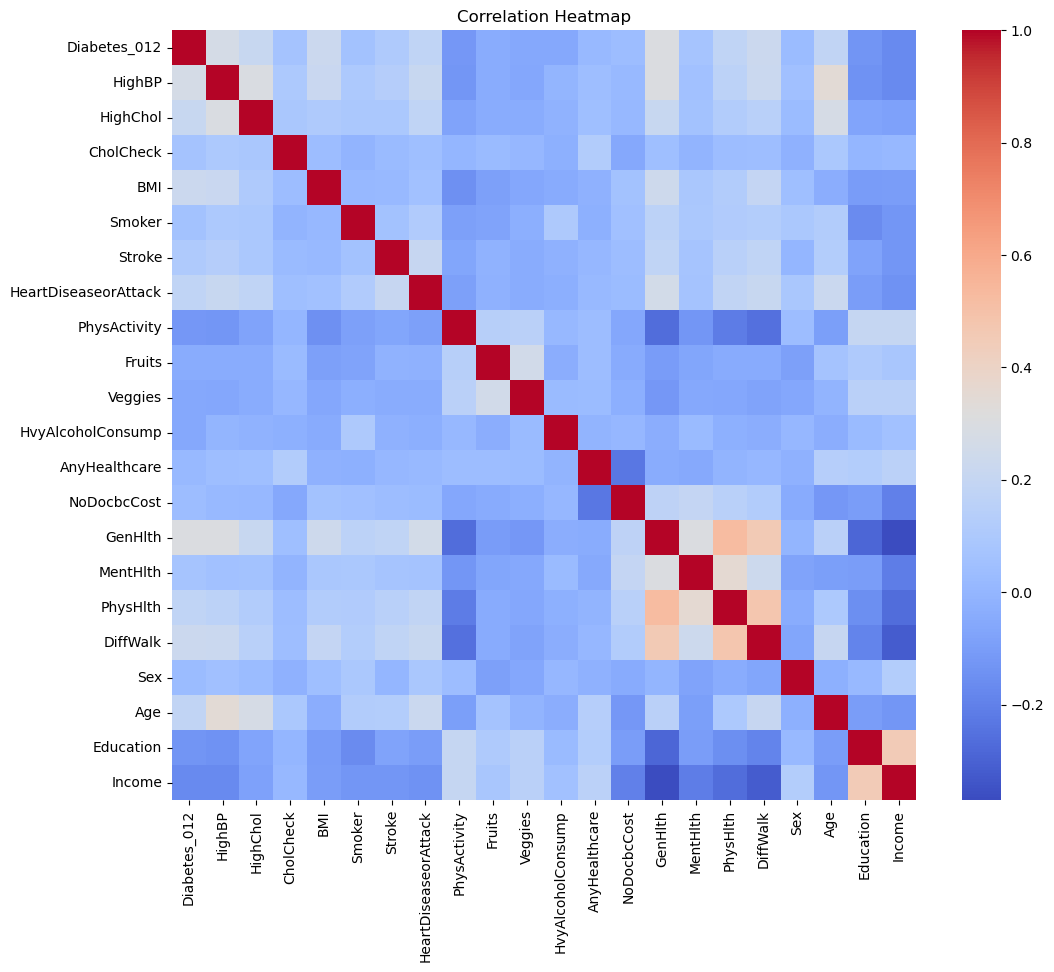

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df.corr()

plt.figure(figsize=(12,10))
sns.heatmap(corr, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

### High BP, HighChol, CholCheck, BMI and Smoker exhibited stronger positive correlations with diabetes than most other variables.

# Chi-Square Tests

In [8]:
from scipy.stats import chi2_contingency

variables = ['HighBP','HighChol','Smoker','PhysActivity']

for var in variables:
    table = pd.crosstab(df['Diabetes_012'], df[var])

    chi2, p, dof, expected = chi2_contingency(table)

    print(f"{var}: p-value = {p}")

HighBP: p-value = 0.0
HighChol: p-value = 0.0
Smoker: p-value = 3.7167324294119075e-220
PhysActivity: p-value = 0.0


### Building prediction model : Random Forest 

In [9]:
from sklearn.model_selection import train_test_split

X = df.drop('Diabetes_012', axis=1)
y = df['Diabetes_012']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [10]:
# Training the model 

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

predictions = rf.predict(X_test)

In [11]:
# Evaluating the model

from sklearn.metrics import classification_report

print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

         0.0       0.86      0.97      0.91     42795
         1.0       0.00      0.00      0.00       944
         2.0       0.47      0.20      0.28      6997

    accuracy                           0.84     50736
   macro avg       0.44      0.39      0.40     50736
weighted avg       0.79      0.84      0.81     50736



In [13]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, predictions)
print("Accuracy:", accuracy)

Accuracy: 0.8412172816146326


In [14]:
import pandas as pd

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance.head(10))

      Feature  Importance
3         BMI    0.184720
18        Age    0.122828
20     Income    0.099751
15   PhysHlth    0.084019
19  Education    0.070048
13    GenHlth    0.067250
14   MentHlth    0.064505
0      HighBP    0.040921
8      Fruits    0.033977
4      Smoker    0.033804


In [15]:
df = pd.read_csv('data/diabetes_binary.csv') #The data values of each building
df

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0,1,1,1,40,1,0,0,0,0,...,1,0,5,18,15,1,0,9,4,3
1,0,0,0,0,25,1,0,0,1,0,...,0,1,3,0,0,0,0,7,6,1
2,0,1,1,1,28,0,0,0,0,1,...,1,1,5,30,30,1,0,9,4,8
3,0,1,0,1,27,0,0,0,1,1,...,1,0,2,0,0,0,0,11,3,6
4,0,1,1,1,24,0,0,0,1,1,...,1,0,2,3,0,0,0,11,5,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
253675,0,1,1,1,45,0,0,0,0,1,...,1,0,3,0,5,0,1,5,6,7
253676,1,1,1,1,18,0,0,0,0,0,...,1,0,4,0,0,1,0,11,2,4
253677,0,0,0,1,28,0,0,0,1,1,...,1,0,1,0,0,0,0,2,5,2
253678,0,1,0,1,23,0,0,0,0,1,...,1,0,3,0,0,0,1,7,5,1


In [16]:
# Check class balance
print(df['Diabetes_binary'].value_counts())
print(df['Diabetes_binary'].value_counts(normalize=True))

# Summary statistics
print(df.describe())

# Check for missing values
print(df.isnull().sum())

# Correlation with target
correlations = df.corr()['Diabetes_binary'].sort_values(ascending=False)
print(correlations)


Diabetes_binary
0    218334
1     35346
Name: count, dtype: int64
Diabetes_binary
0    0.860667
1    0.139333
Name: proportion, dtype: float64
       Diabetes_binary         HighBP       HighChol      CholCheck  \
count    253680.000000  253680.000000  253680.000000  253680.000000   
mean          0.139333       0.429001       0.424121       0.962670   
std           0.346294       0.494934       0.494210       0.189571   
min           0.000000       0.000000       0.000000       0.000000   
25%           0.000000       0.000000       0.000000       1.000000   
50%           0.000000       0.000000       0.000000       1.000000   
75%           0.000000       1.000000       1.000000       1.000000   
max           1.000000       1.000000       1.000000       1.000000   

                 BMI         Smoker         Stroke  HeartDiseaseorAttack  \
count  253680.000000  253680.000000  253680.000000         253680.000000   
mean       28.382364       0.443169       0.040571              0

In [17]:
# And some function we will need
from statsmodels.discrete.discrete_model import Logit
from scipy.special import logit

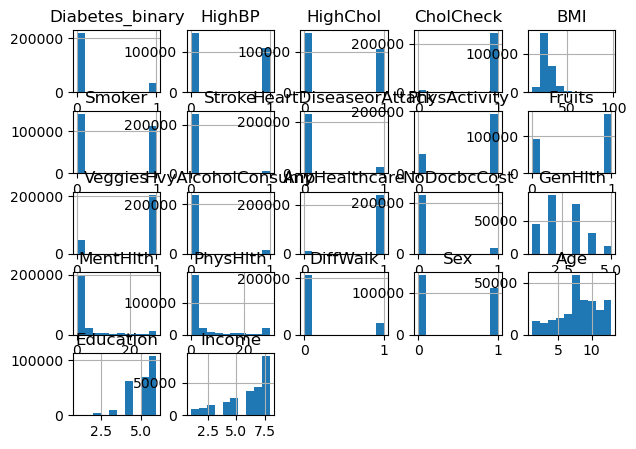

In [18]:
df.hist(figsize=(7,5))
plt.show()

In [23]:
df.columns[df.columns.str.contains("GenHlth")]

Index(['GenHlth', 'GenHlth_1', 'GenHlth_2', 'GenHlth_3', 'GenHlth_4',
       'GenHlth_5'],
      dtype='object')

In [22]:
dummy_genhlth = pd.get_dummies(df['GenHlth'], prefix='GenHlth')
df = df.join(dummy_genhlth)
df.loc[:, 'Intercept'] = np.ones(df.shape[0])

ValueError: columns overlap but no suffix specified: Index(['GenHlth_1', 'GenHlth_2', 'GenHlth_3', 'GenHlth_4', 'GenHlth_5'], dtype='object')

In [24]:
# Fit the model
predictors = [
    'BMI',
    'Age',
    'HighBP',
    'HighChol',
    'GenHlth',
    'Intercept'
]
m = Logit(df['Diabetes_binary'], df[predictors])
m = m.fit()


Optimization terminated successfully.
         Current function value: 0.323795
         Iterations 7


In [25]:
m.params

BMI          0.062680
Age          0.141790
HighBP       0.807767
HighChol     0.600655
GenHlth      0.580049
Intercept   -7.354235
dtype: float64

In [26]:
print(m.summary2())

                          Results: Logit
Model:              Logit            Method:           MLE        
Dependent Variable: Diabetes_binary  Pseudo R-squared: 0.198      
Date:               2026-07-22 19:24 AIC:              164292.5421
No. Observations:   253680           BIC:              164355.2050
Df Model:           5                Log-Likelihood:   -82140.    
Df Residuals:       253674           LL-Null:          -1.0242e+05
Converged:          1.0000           LLR p-value:      0.0000     
No. Iterations:     7.0000           Scale:            1.0000     
-------------------------------------------------------------------
              Coef.   Std.Err.      z      P>|z|    [0.025   0.975]
-------------------------------------------------------------------
BMI           0.0627    0.0009    71.1313  0.0000   0.0610   0.0644
Age           0.1418    0.0026    54.2647  0.0000   0.1367   0.1469
HighBP        0.8078    0.0146    55.2721  0.0000   0.7791   0.8364
HighChol      0

In [27]:
df.loc[:, 'p'] = m.predict(df[predictors])

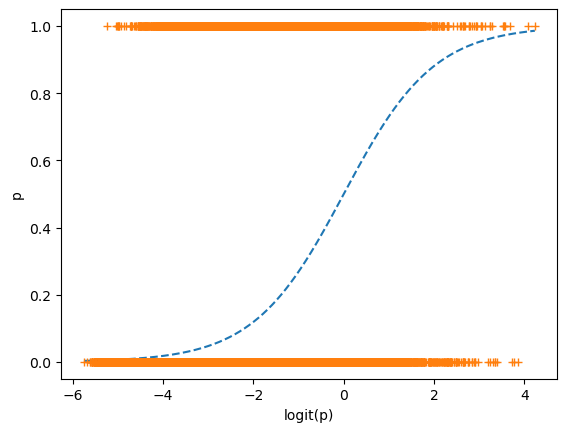

In [28]:
df = df.sort_values(by = ['p'], axis = 0)
plt.plot(logit(df.p), df.p, '--')
plt.plot(logit(df.p), df.Diabetes_binary, '+')
plt.xlabel('logit(p)')
plt.ylabel('p')
plt.show()

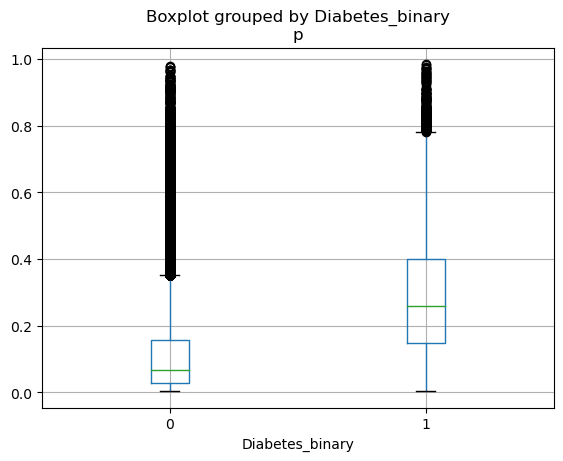

In [29]:
df.boxplot(column='p', by='Diabetes_binary')
plt.show()

In [30]:
df.loc[:, 'yhat'] = (df.p > 0.5) * 1
df.yhat.value_counts()

yhat
0    244512
1      9168
Name: count, dtype: int64

In [32]:
pd.crosstab(df.Diabetes_binary, df.yhat)

yhat,0,1
Diabetes_binary,,
0,214034,4300
1,30478,4868


In the confusion matrix above, we see that we have 214034 cases when diabetes was correctly estimated as non existent and 4868 cases when it was correctly estimated as a diagnosis. The remaining 4300 + 30478 estimates were incorrect.